In [1]:
from itertools import accumulate
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import RocCurveDisplay

In [2]:
dataset_dir = Path('datasets')
results_dir = Path('results')

## PPCA

In [3]:
train_data = np.load(dataset_dir / 'pav_features/train_split.npy')
valid_data = np.load(dataset_dir / 'pav_features/valid_split.npy')
iterations = sorted(list((results_dir / 'ppca').glob('iteration_*')))
iteration_defec = []
iteration_clean = []
defec_loglike = []
clean_loglike = []
evals = []
for iteration in iterations:
    valid_eval = np.load(iteration / 'valid.npy')
    evals.append(valid_eval)
    defec_mask = valid_eval[:, 0].astype(bool)
    defec_loglike.append(valid_eval[defec_mask, 1].sum())
    clean_loglike.append(valid_eval[~defec_mask, 1].sum())
    with (iteration / 'defec_image_paths.txt').open('r') as f:
        iteration_defec.append(f.read().splitlines())
    with (iteration / 'clean_image_paths.txt').open('r') as f:
        iteration_clean.append(f.read().splitlines())

### Número de imagens com defeito encontradas em cada iteração
A expectativa é que o número de imagens com defeitos aumente em cada nova seleção de imagens, umas vez que as imagens selecionadas são aquelas com as menores probabilidade segundo a distribuição marginal das imagens sem defeitos.

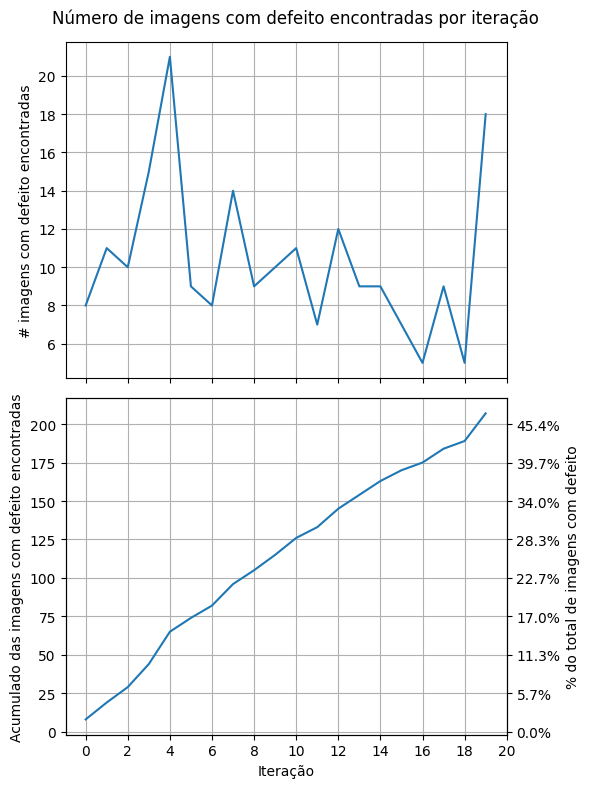

In [4]:
defecs_counts = [len(paths) for paths in iteration_defec]
defecs_accumu = list(accumulate(defecs_counts))
total_defecs = train_data[:, -1].sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
ax1.plot(defecs_counts)
ax1.set_ylabel('# imagens com defeito encontradas')
ax1.grid(True)
ax2.plot(defecs_accumu)
ax2.set_ylabel('Acumulado das imagens com defeito encontradas')
ax2.set_xlabel('Iteração')
ax2.set_xticks(range(0, len(defecs_counts) + 1, 2))
ax2.grid(True)
ax3 = ax2.twinx()
lims = ax2.get_ylim()
ax3.set_ylim(lims)
formatter = mticker.PercentFormatter(xmax=total_defecs)
ax3.yaxis.set_major_formatter(formatter)
ax3.set_ylabel('% do total de imagens com defeito')
fig.suptitle('Número de imagens com defeito encontradas por iteração')
plt.tight_layout()
plt.show()

### Avaliação das distribuições segundo conjunto de validação

#### Log-verossimilhança total

Com o passar das iterações e novas imagens sem defeitos surgem, a expectativa é que a estimação de densidade das imagens sem defeitos melhore. Essa melhora pode ser mensurada usando o conjunto de validação. Espera-se que a log-verossimilhança total das imagens sem defeitos presentes no conjunto de validação aumente com o passar das iterações e que a log-verossimilhança total das imagens com defeitos diminua.

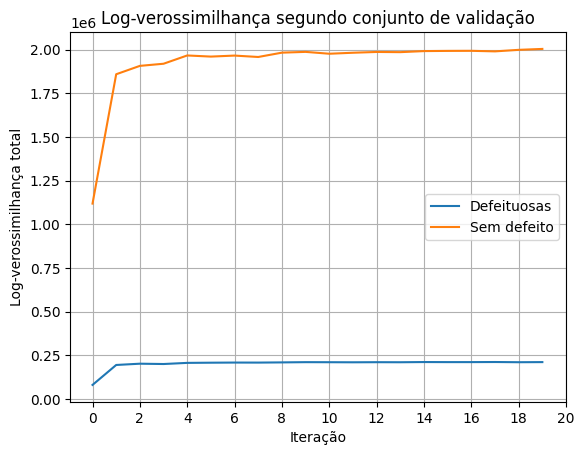

In [5]:
plt.plot(defec_loglike, label='Defeituosas')
plt.plot(clean_loglike, label='Sem defeito')
plt.xlabel('Iteração')
plt.ylabel('Log-verossimilhança total')
plt.xticks(range(0, len(defec_loglike) + 1, 2))
plt.grid()
plt.title('Log-verossimilhança segundo conjunto de validação')
plt.legend()
plt.show()

#### Curvas ROC

A cada iteração, novas estimações de densidade são obtidas. Outra forma de avaliar a qualidade da estimação da distribuição marginal $p_{limpas}(x)$ é analisando a curva ROC obtida a partir dos rótulos e dos valores de logpdf da distribuição marginal para cada imagem no conjunto de validação.

Uma vez que a curva ROC espera pontuações maiores para a classe alvo (anomalias, ou seja, imagens com defeitos), em vez da pontuação ser $\log{p_{limpas}(x_{vi})}$ ($x_{vi}$ sendo a i-ésima imagem do conjunto de validação) ela será a negativa desse valor.

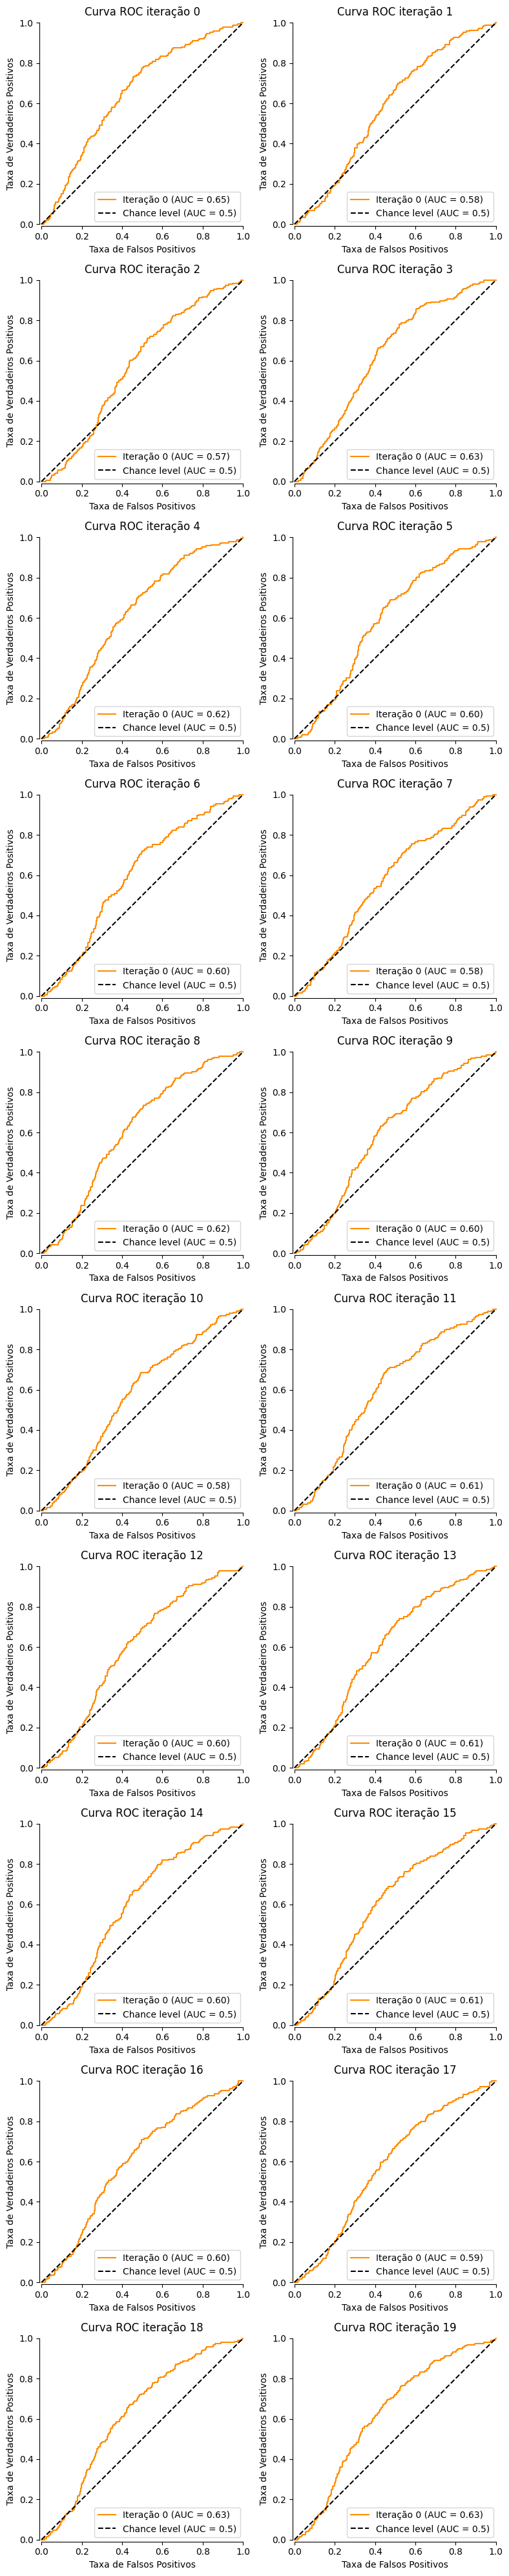

In [6]:
num_images = accumulate([len(p) for p in iteration_clean])
fig, axs = plt.subplots(10, 2, figsize=(8, 40))

for iteration, valid_eval in enumerate(evals):
    i, j = divmod(iteration, 2)
    ax = axs[i, j]
    display = RocCurveDisplay.from_predictions(
        evals[iteration][:, 0],
        -evals[iteration][:, 1],
        name='Iteração 0',
        curve_kwargs=dict(color="darkorange"),
        plot_chance_level=True,
        despine=True,
        ax=axs[i, j],
    )
    display.ax_.set(
        title=f'Curva ROC iteração {iteration}',
        xlabel='Taxa de Falsos Positivos',
        ylabel='Taxa de Verdadeiros Positivos',
    )
plt.tight_layout()
plt.show()